In [2]:
import pandas as pd


In [6]:
df = pd.read_csv('fake_job_postings.csv', engine='python', on_bad_lines='skip')
print(df.shape)
print(df.columns.tolist())
print(df['fraudulent'].value_counts())
print(df.isnull().sum())

(17880, 18)
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']
fraudulent
0    17014
1      866
Name: count, dtype: int64
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [7]:
# Class distribution percentage
print(df['fraudulent'].value_counts(normalize=True) * 100)

# Check binary columns
print(df[['telecommuting', 'has_company_logo', 'has_questions']].describe())

# Fraudulent rate by company logo
print(df.groupby('has_company_logo')['fraudulent'].mean())

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64
       telecommuting  has_company_logo  has_questions
count   17880.000000      17880.000000   17880.000000
mean        0.042897          0.795302       0.491723
std         0.202631          0.403492       0.499945
min         0.000000          0.000000       0.000000
25%         0.000000          1.000000       0.000000
50%         0.000000          1.000000       0.000000
75%         0.000000          1.000000       1.000000
max         1.000000          1.000000       1.000000
has_company_logo
0    0.159290
1    0.019902
Name: fraudulent, dtype: float64


In [8]:
# Fraud rate by telecommuting
print(df.groupby('telecommuting')['fraudulent'].mean())

# Fraud rate by has_questions
print(df.groupby('has_questions')['fraudulent'].mean())

# Fraud rate by employment type
print(df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False))

# Fraud rate by required experience
print(df.groupby('required_experience')['fraudulent'].mean().sort_values(ascending=False))

telecommuting
0    0.046865
1    0.083442
Name: fraudulent, dtype: float64
has_questions
0    0.067782
1    0.028435
Name: fraudulent, dtype: float64
employment_type
Part-time    0.092848
Other        0.066079
Full-time    0.042169
Contract     0.028871
Temporary    0.008299
Name: fraudulent, dtype: float64
required_experience
Executive           0.070922
Entry level         0.066370
Not Applicable      0.053763
Director            0.043702
Mid-Senior level    0.029667
Internship          0.026247
Associate           0.018285
Name: fraudulent, dtype: float64


In [9]:
# Combine key text columns into one
df['text'] = df['title'].fillna('') + ' ' + \
             df['description'].fillna('') + ' ' + \
             df['requirements'].fillna('') + ' ' + \
             df['company_profile'].fillna('')

# Average text length for real vs fake
df['text_length'] = df['text'].apply(len)
print(df.groupby('fraudulent')['text_length'].mean())

fraudulent
0    2490.859880
1    1865.442263
Name: text_length, dtype: float64


In [10]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Check before and after
print(df['text'].iloc[0][:200])
print("---")
print(df['clean_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Marketing Intern Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work 
---
marketing intern food fastgrowing james beard awardwinning online food community crowdsourced curated recipe hub currently interviewing full parttime unpaid interns work small team editors executives 


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import numpy as np

# TF-IDF on cleaned text
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['clean_text'])

# Combine with numerical features
numerical_features = df[['telecommuting', 'has_company_logo',
                          'has_questions', 'text_length']].values

X_combined = sp.hstack([X_text, sp.csr_matrix(numerical_features)])
y = df['fraudulent']

print("X shape:", X_combined.shape)
print("y shape:", y.shape)

X shape: (17880, 5004)
y shape: (17880,)


In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))

Before SMOTE: {0: 13611, 1: 693}
After SMOTE: {np.int64(0): np.int64(13611), np.int64(1): np.int64(13611)}


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.61      0.87      0.72       173

    accuracy                           0.97      3576
   macro avg       0.80      0.92      0.85      3576
weighted avg       0.97      0.97      0.97      3576

[[3308   95]
 [  23  150]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.65      0.79       173

    accuracy                           0.98      3576
   macro avg       0.99      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576

[[3402    1]
 [  60  113]]


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.93      0.72      0.81       173

    accuracy                           0.98      3576
   macro avg       0.96      0.86      0.90      3576
weighted avg       0.98      0.98      0.98      3576

[[3394    9]
 [  48  125]]


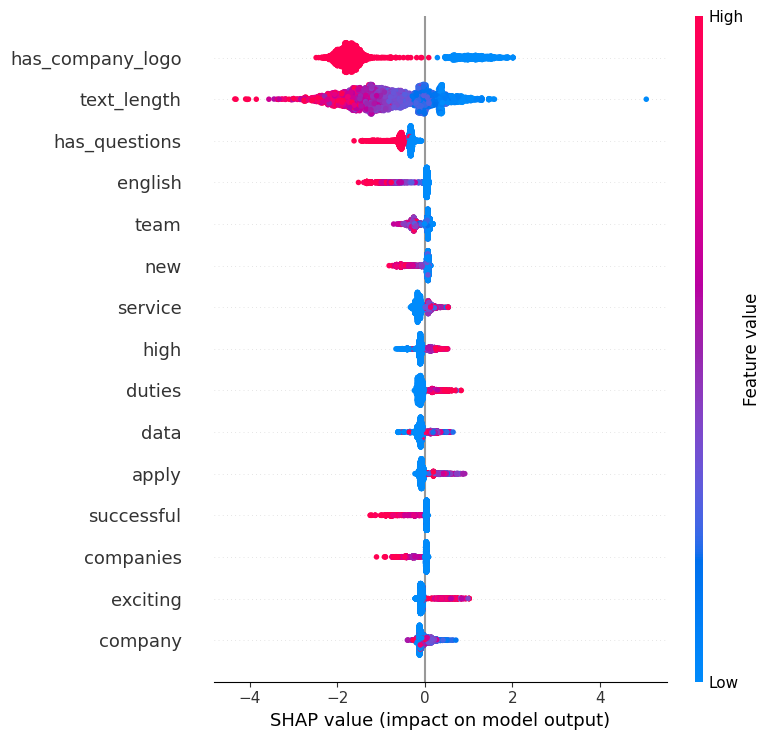

In [16]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Get feature names
text_features = tfidf.get_feature_names_out().tolist()
num_features = ['telecommuting', 'has_company_logo', 'has_questions', 'text_length']
all_features = text_features + num_features

# Summary plot
shap.summary_plot(shap_values, X_test.toarray(),
                  feature_names=all_features, max_display=15)